# EDA

## Import libraries

In [33]:
# Import libraries required 
# for data analysis
import pandas as pd
import numpy as np

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Load Dataset

In [34]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('../data/ai4i2020.csv')

# Initial Checks

In [35]:
# Display the first few rows of the dataset
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [36]:
# Check for missing values
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [37]:
# Check data types of each column
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

# Distribution Checks

### Class Imbalance

In [38]:
# Check for skewness in the target variable
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

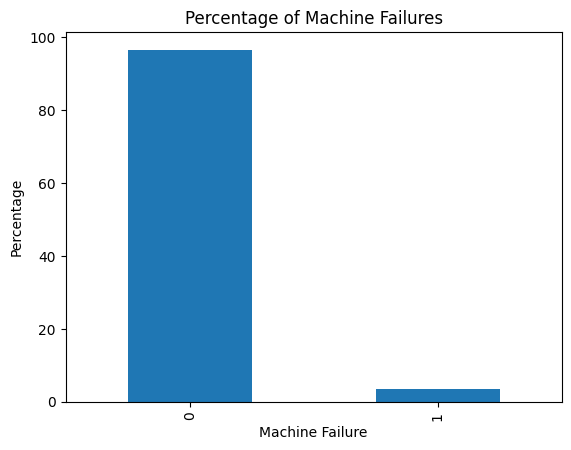

In [39]:
# Check visually for skewness in the target variable
# by plotting the failure counts as percentages
failure_counts = df['Machine failure'].value_counts(normalize=True) * 100
failure_counts.plot(kind='bar')
plt.xlabel('Machine Failure')
plt.ylabel('Percentage')
plt.title('Percentage of Machine Failures')
plt.show()

Failures make up roughly 3.4% of all observations — the remaining 96.6% are non-failure records. This strong imbalance means a classifier that always predicts "no failure" would still score over 96% on raw accuracy, so standard accuracy alone will not be a reliable yardstick when evaluating models.

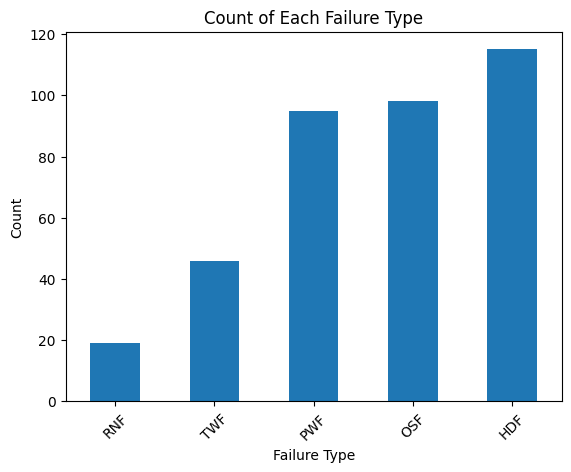

In [40]:
# Check individual failure types
failure_cols = [
    'TWF',  # Tool wear failure
    'HDF',  # Heat dissipation failure
    'PWF',  # Power failure
    'OSF',  # Overstrain failure
    'RNF'   # Random failures
]

df[failure_cols].sum().sort_values().plot(kind='bar')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.title('Count of Each Failure Type')
plt.xticks(rotation=45)
plt.show()

OSF (Overstrain Failure) and PWF (Power Failure) are the most frequent individual failure modes, while RNF (Random Failure) occurs only a handful of times. The uneven spread across failure types suggests that each mode may have a distinct relationship to the operational features — and that RNF, being rare and by definition unpredictable, may be the hardest to model.

### Feature Distribution

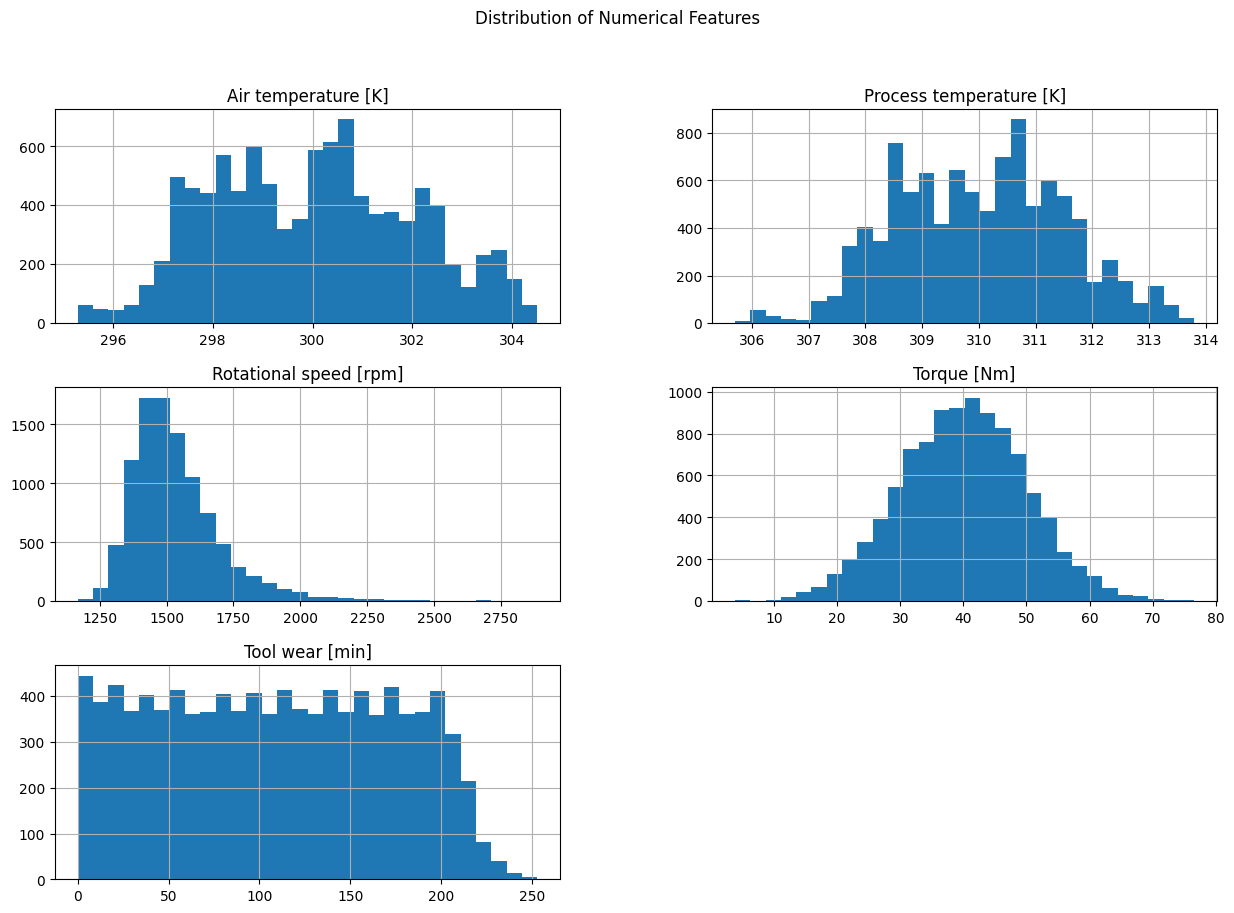

In [41]:
# Understand shape of each numerical feature
num_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df[num_cols].hist(figsize=(15,10), bins=30)
plt.suptitle('Distribution of Numerical Features')
plt.show()

Air temperature and process temperature show a mild, roughly symmetric shape across a narrow range in the mid-300 K, while rotational speed is right-skewed with a long upper tail. Torque is approximately normally distributed. Tool wear shows an asymmetric distribution — the machine operates most often at moderate wear levels, with occasional long-wear episodes extending the right side of the histogram.

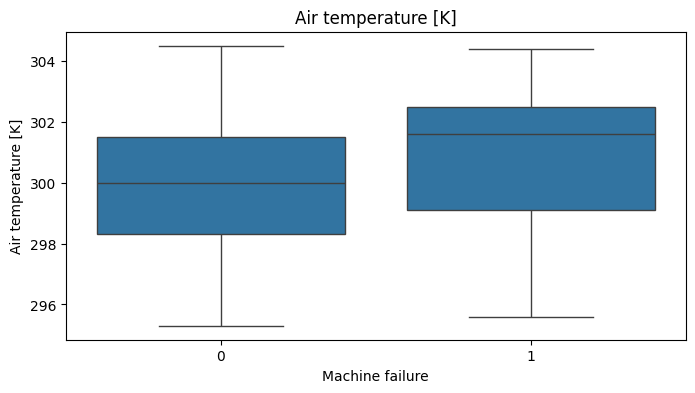

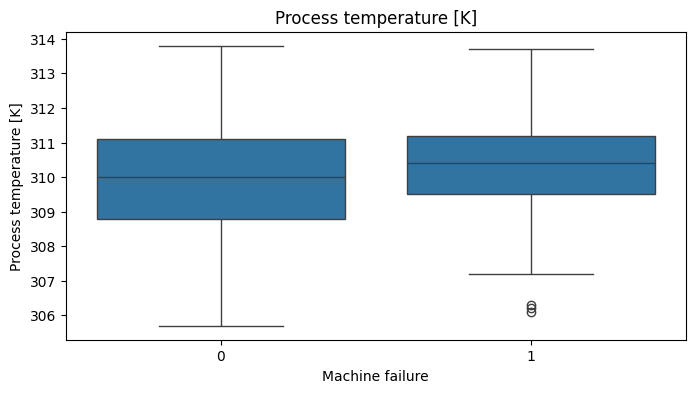

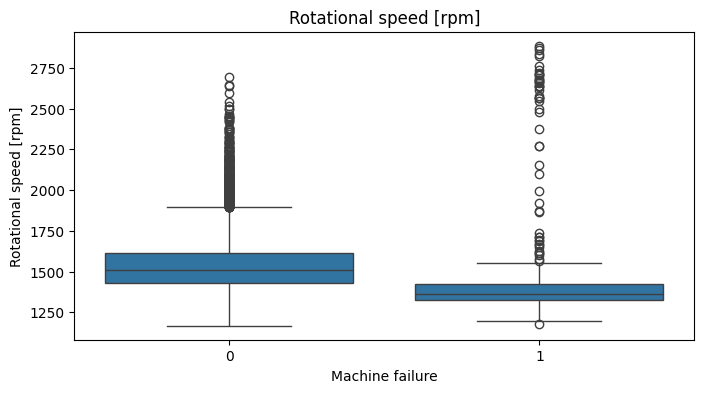

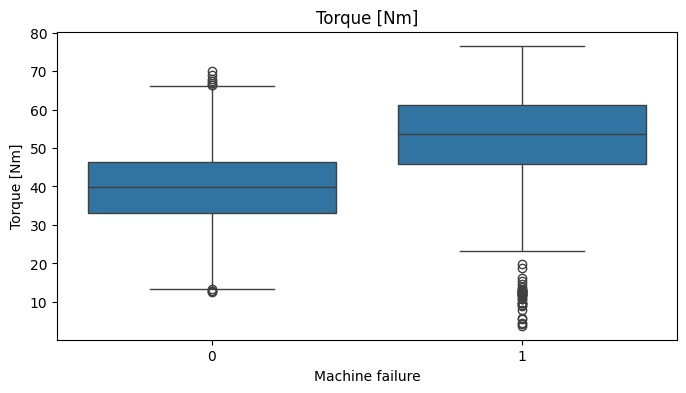

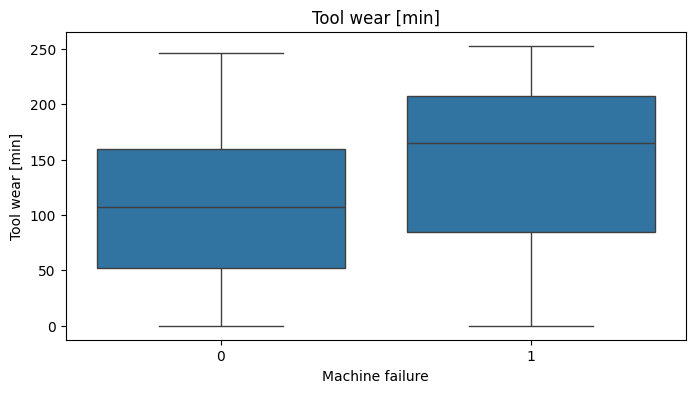

In [42]:
# Plot boxplots by failure status for numerical features
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Machine failure', y=col, data=df)
    plt.title(col)
    plt.show()

Several features — most visibly torque and rotational speed — show a shift in their median values between the failure and non-failure groups, and failure records tend to show wider spreads with more outliers, especially for the torque chart.

## Correlation Analysis

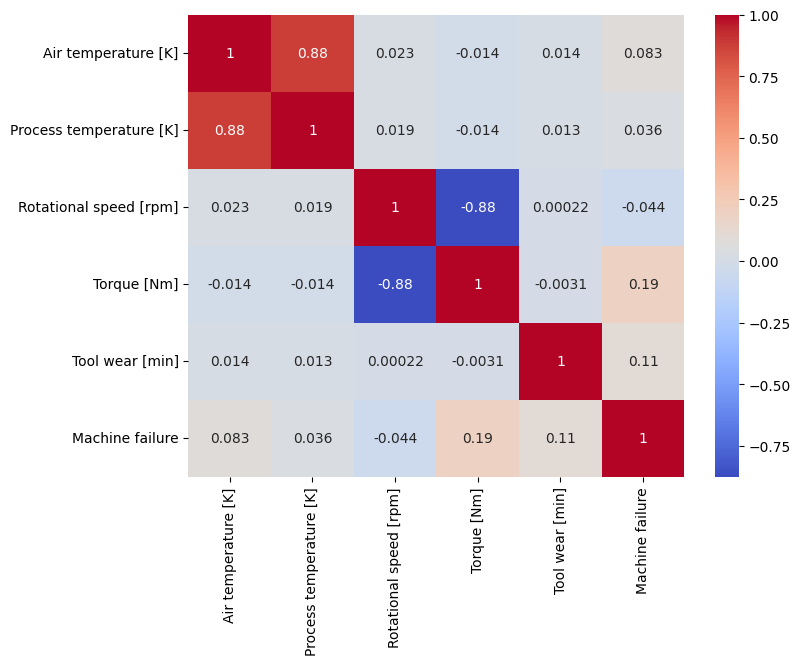

In [43]:
# Check relationships between operational variables
corr = df[num_cols + ['Machine failure']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Torque and rotational speed carry a moderate negative correlation (~−0.87), reflecting the physical trade-off between load and speed in rotating machinery. Machine failure itself shows only weak linear correlations with any individual feature, which suggests that failure is driven by combinations of conditions rather than by any one variable crossing a threshold.

## Feature Relationship

/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide

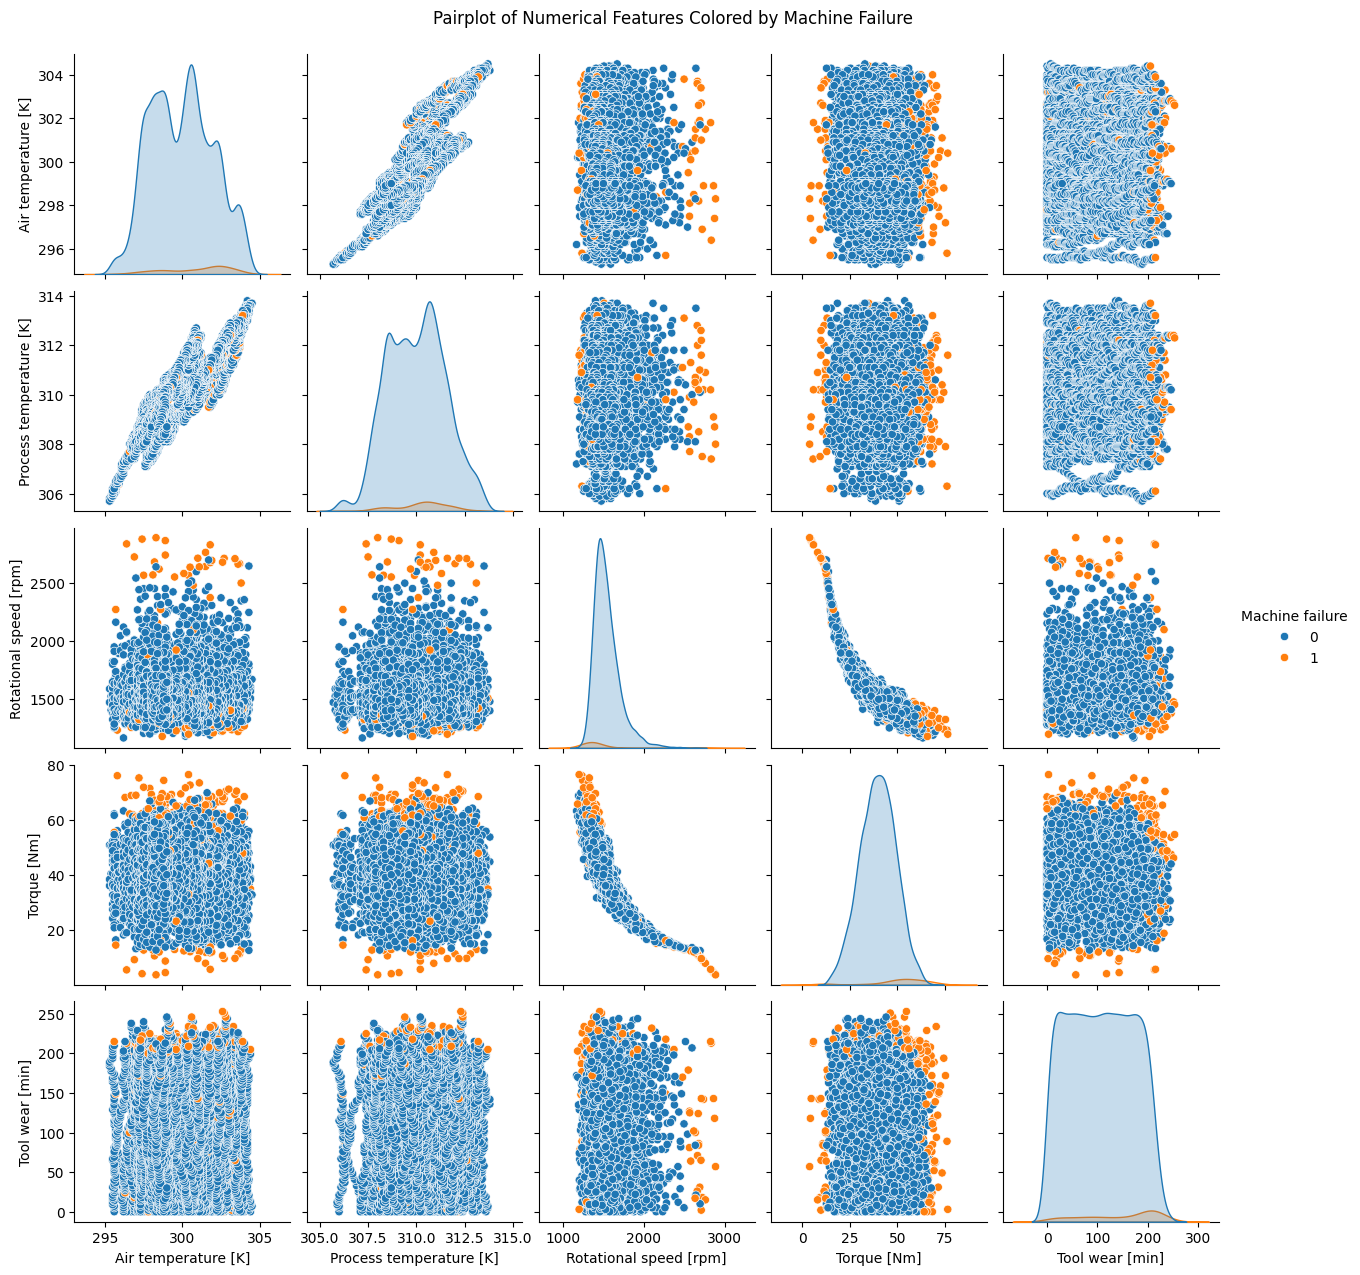

In [44]:
# Use pairplot to visualize relationships between features colored by failure status
sns.pairplot(df[num_cols + ['Machine failure']], hue='Machine failure', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features Colored by Machine Failure', y=1.02)
plt.show()

Failure points (orange) do not form isolated clusters in most pairwise plots, but a visible band of failures appears in the torque–rotational speed panel at extreme combinations either of high torque and low speed and vice versa. The diagonal Kernel Density Estimation (KDE) curves show that the failure class partially overlaps with the non-failure class for every individual feature, reinforcing that meaningful boundaries will need to be learned from multiple features working together.

## Detailed Investigation of Feature Interactions

### Tool Wear vs Torque

Investigate the cumulative mechanical burden

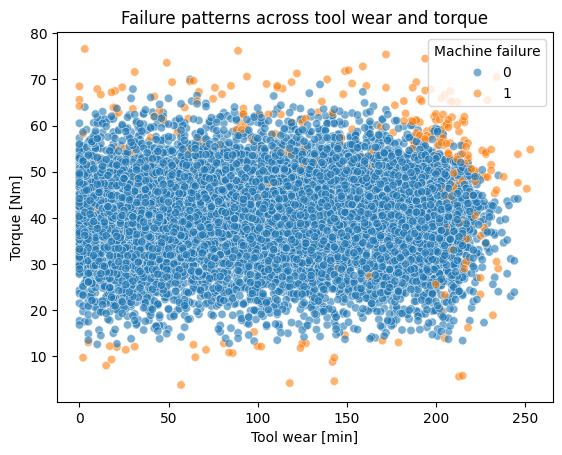

In [45]:
# Visualize the relationship between thermal and mechanical stress colored by failure status
sns.scatterplot(
    data=df,
    x='Tool wear [min]',
    y='Torque [Nm]',
    hue='Machine failure',
    alpha=0.6
)

plt.title("Failure patterns across tool wear and torque")
plt.show()

In [46]:
fig = px.scatter(
    df,
    x="Tool wear [min]",
    y="Torque [Nm]",
    color=df["Machine failure"].astype(str),   # cast to string → categorical
    color_discrete_map={"0": "#636EFA", "1": "#FF0000"},  # keys must be strings too
    opacity=0.6,
    template="plotly_dark",
    title="Failure patterns across tool wear and torque",
    labels={"color": "Machine failure"},
)
fig.update_layout(
    xaxis_title="Tool wear [min]",
    yaxis_title="Torque [Nm]",
)
fig.show()


Failure points are spread broadly across the edges of the scatter plot rather than forming a tight cluster, though a slight concentration is visible at mid-to-high torque values combined with elevated tool wear. This spread suggests that high cumulative wear alone does not guarantee failure — the level of torque applied to a worn tool appears to matter as well.

### Air temperature vs rotational speed

In [76]:
fig = px.scatter(
    df,
    x="Process temperature [K]",
    y="Rotational speed [rpm]",
    color=df["Machine failure"].astype(str),   # cast to string → categorical
    color_discrete_map={"0": "#636EFA", "1": "#FF0000"},  # keys must be strings too
    #opacity=0.6,
    template="plotly_dark",
    title="Failure patterns across process temperature and rotational speed",
    labels={"color": "Machine failure"},
)
fig.update_layout(
    xaxis_title="Process Temperature [K]",
    yaxis_title="Rotational Speed [rpm]",
    # increase font size for better readability
    font=dict(size=20)
)
fig.show()


### Torque-Speed Interaction

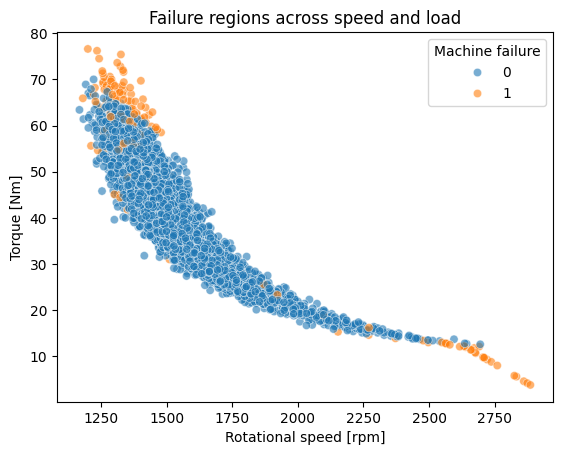

In [48]:
# Visualize the relationship between rotational speed and torque colored by failure status
sns.scatterplot(
    data=df,
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    hue='Machine failure',
    alpha=0.6
)

plt.title("Failure regions across speed and load")
plt.show()

A curved boundary is visible in the scatter: failures cluster at the outer edges of the speed–torque space — low speed with high torque, and high speed with low torque — while the center of the distribution is almost entirely failure-free. This pattern is consistent with the idea of a safe operating band, where combined speed and load extremes are where the machine is most at risk.

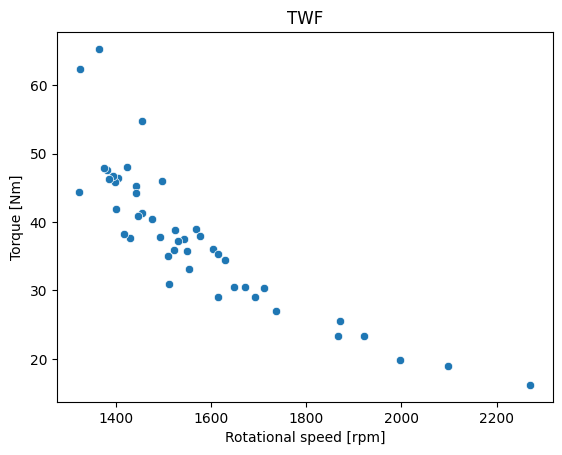

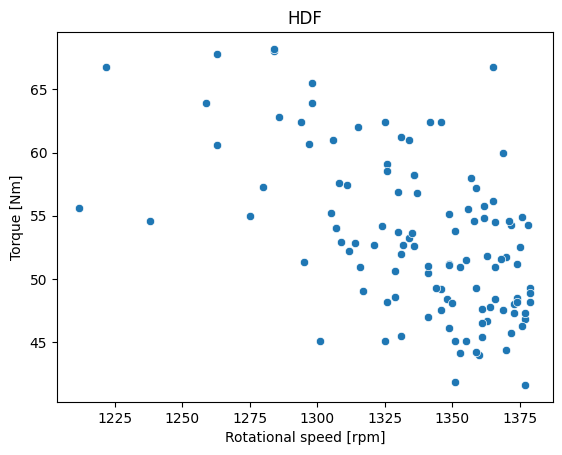

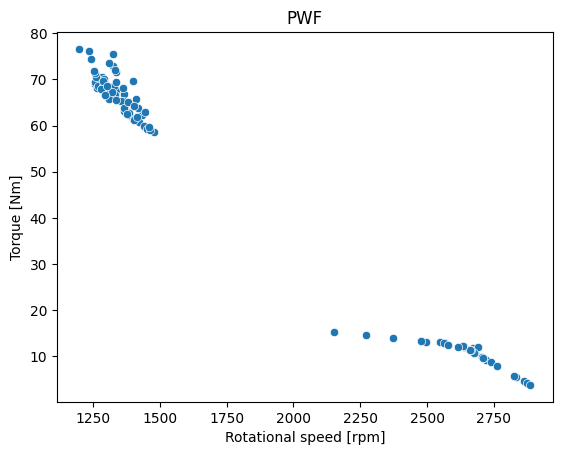

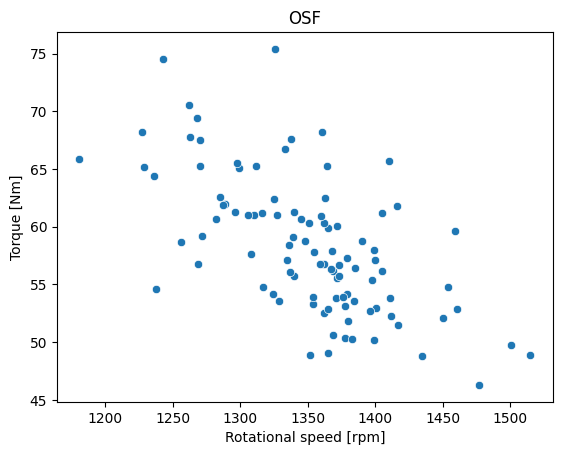

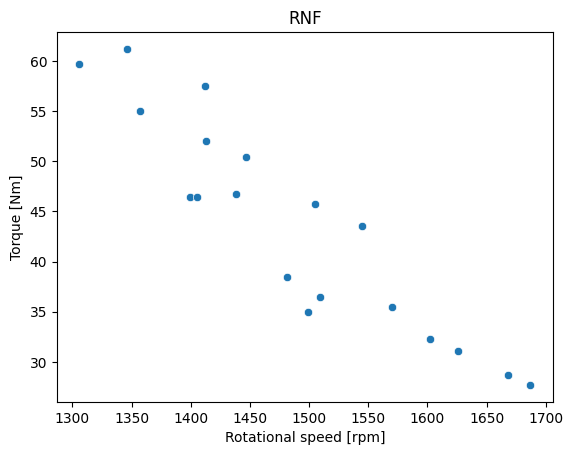

In [49]:
# Plot the relationship by failure type
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for col in failure_cols:
    sns.scatterplot(
        data=df[df[col] == 1],
        x='Rotational speed [rpm]',
        y='Torque [Nm]'
    )
    plt.title(col)
    plt.show()

PWF events appear toward the outer edges of the speed range in both directions, driving the general failure rate pattern in this direction.

## Derived Features Exploration

### Mechanical Stress

Captures accumulated operational burden as a product of torque and tool wear. 

High torque alone may be okay. High tool wear alone may be okay. But high torque on a worn tool is often dangerous.

/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


<Axes: xlabel='Mechanical_stress', ylabel='Count'>

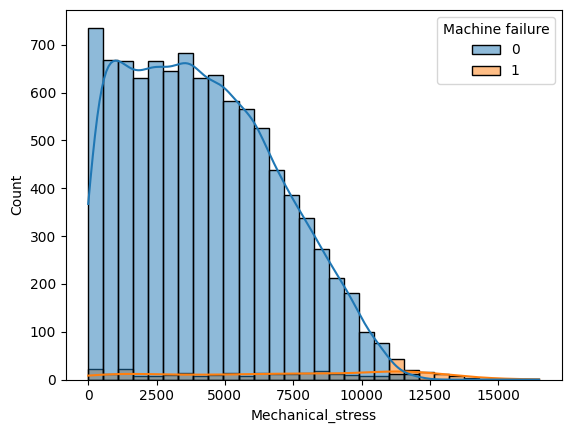

In [50]:
# Mechanical stress as product of torque and tool wear
df['Mechanical_stress'] = df['Torque [Nm]'] * df['Tool wear [min]']

# Visualize distribution of mechanical stress by failure status
sns.histplot(
    data=df,
    x='Mechanical_stress',
    hue='Machine failure',
    kde=True,
    bins=30
)

The mechanical stress distribution is mildly right-skewed: most observations sit at low stress values, with no meaningful heavy tail. Failure records are more densely represented in the upper portion of that tail, though non-failure observations still make up the majority even there — pointing to elevated but not certain risk at high stress levels.

/var/folders/1h/ym65mz2s4fv2m61786s8zy7m0000gn/T/ipykernel_30603/585198113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('stress_bin')['Machine failure']


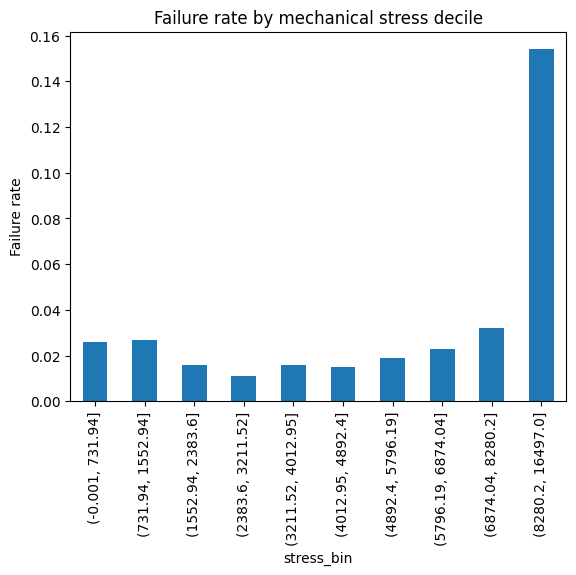

In [51]:
# Bin mechanical stress into deciles and calculate failure rate in each bin
df['stress_bin'] = pd.qcut(df['Mechanical_stress'], 10)

(
    df.groupby('stress_bin')['Machine failure']
    .mean()
    .plot(kind='bar')
)

plt.ylabel("Failure rate")
plt.title("Failure rate by mechanical stress decile")
plt.show()

The bar chart shows that the bottom eight deciles have low and relatively similar failure rates, while the top two deciles rise noticeably. The line chart below makes the shape of that increase easier to read.

/var/folders/1h/ym65mz2s4fv2m61786s8zy7m0000gn/T/ipykernel_30603/4018091740.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['Mechanical_stress'], 10))['Machine failure'].mean().plot()


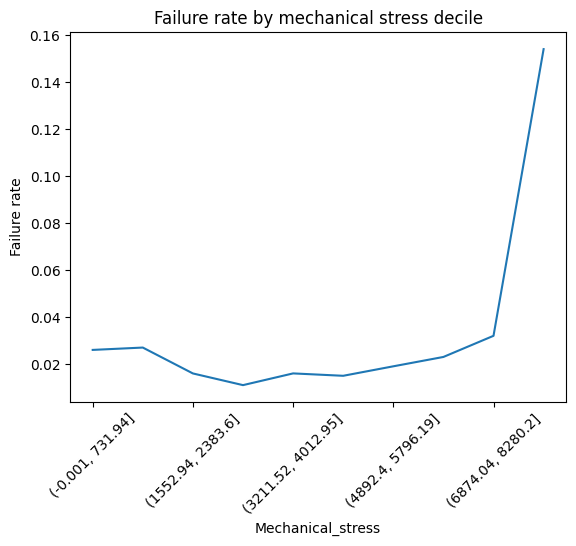

In [52]:
# Alternatively, plot as line plot and turn the x labels
df.groupby(pd.qcut(df['Mechanical_stress'], 10))['Machine failure'].mean().plot()
plt.xticks(rotation=45)
plt.ylabel("Failure rate")
plt.title("Failure rate by mechanical stress decile")
plt.show()

Failure rate stays near zero through the lower eight deciles and then rises sharply in the top two — a step-change rather than a gradual climb. This non-linear threshold effect suggests that mechanical stress is most informative at the high end of its range, and that the feature's predictive value is concentrated in a relatively small portion of the data.

### Torque-Temperature interaction

A machine under both:
- high torque
- elevated operating temperature

is under compounded stress.

/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


<Axes: xlabel='Temp_Torque_interaction', ylabel='Count'>

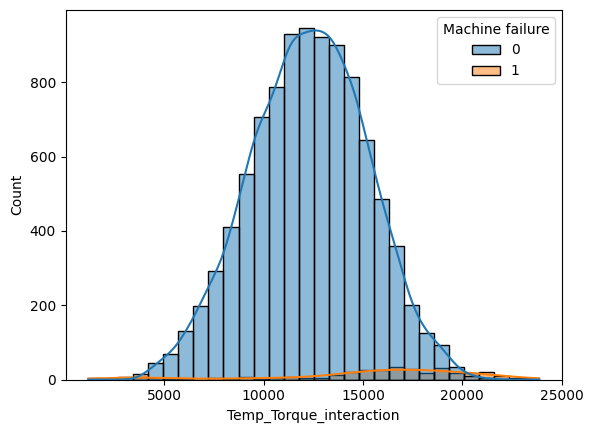

In [53]:
# Calculate the temperature-torque interaction as product of process temperature and torque
df['Temp_Torque_interaction'] = df['Process temperature [K]'] * df['Torque [Nm]']

# Visualize the temperature-torque interaction by failure status
sns.histplot(
    data=df,
    x='Temp_Torque_interaction',
    hue='Machine failure',
    kde=True,
    bins=30
)

The temperature–torque interaction distribution is roughly bell-shaped; failures appear across the full range but are proportionally more visible in the upper tail. The substantial overlap between failure and non-failure distributions confirms that high combined thermal and mechanical load raises risk, but does not on its own determine the outcome.

/var/folders/1h/ym65mz2s4fv2m61786s8zy7m0000gn/T/ipykernel_30603/3662552561.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['Temp_Torque_interaction'], 10))['Machine failure'].mean().plot()


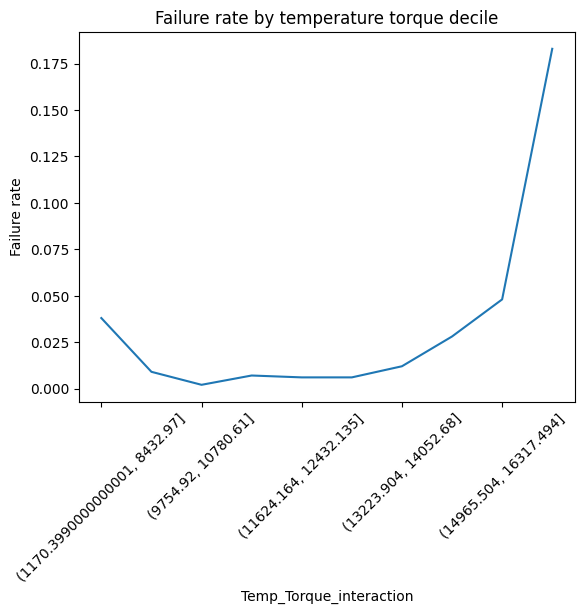

In [54]:
# Plot as line plot in decentiles and against failure rate
df.groupby(pd.qcut(df['Temp_Torque_interaction'], 10))['Machine failure'].mean().plot()
plt.xticks(rotation=45)
plt.ylabel("Failure rate")
plt.title("Failure rate by temperature torque decile")
plt.show()

Failure rate climbs steeply in the highest temperature–torque deciles, mirroring the pattern seen with mechanical stress. The lower mid section of the distribution shows near-zero failure rates, while the top three deciles account for a disproportionate share of all failures — consistent with the idea that compounded thermal and mechanical load has a cumulative effect.

### Load-Speed Ratio
Reflects operational strain efficiency.

- High torque at low rotational speed often implies heavy resistance/load
- Can indicate overload conditions

Potentially relevant for overstrain failures (OSF).

/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


<Axes: xlabel='Load_speed_ratio', ylabel='Count'>

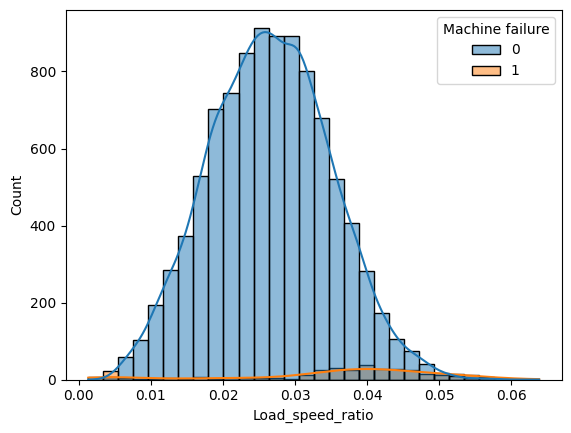

In [55]:
# Calculate the load-speed ratio as torque divided by rotational speed
df['Load_speed_ratio'] = (
    df['Torque [Nm]'] / df['Rotational speed [rpm]']
)

# Visualize the load-speed ratio by failure status
sns.histplot(
    data=df,
    x='Load_speed_ratio',
    hue='Machine failure',
    kde=True,
    bins=30
)

Load-speed ratio values are concentrated at low positive values; failure events are present throughout but appear more frequently at higher ratio values. The shape indicates that most operations occur at moderate load-to-speed conditions, with heavy-load, low-speed episodes being relatively rare but more often associated with failure.

/var/folders/1h/ym65mz2s4fv2m61786s8zy7m0000gn/T/ipykernel_30603/3269174401.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['Load_speed_ratio'], 10))['Machine failure'].mean().plot()


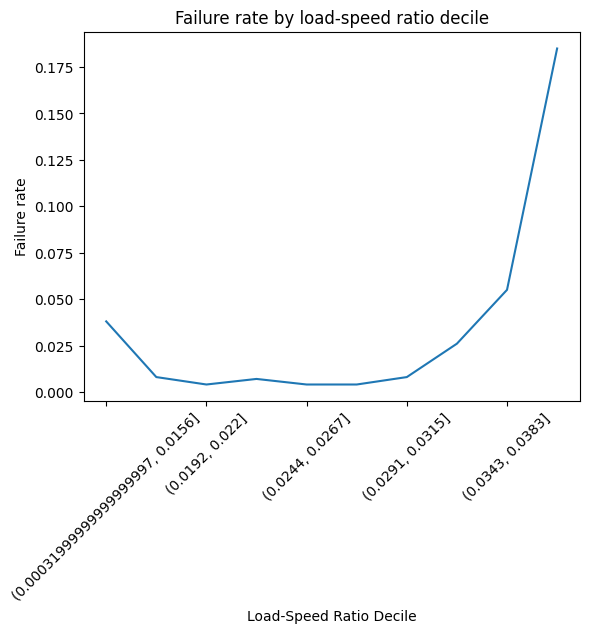

In [56]:
# Plot as line plot in decentiles and against failure rate
df.groupby(pd.qcut(df['Load_speed_ratio'], 10))['Machine failure'].mean().plot()
plt.xticks(rotation=45)
plt.xlabel("Load-Speed Ratio Decile")
plt.ylabel("Failure rate")
plt.title("Failure rate by load-speed ratio decile")
plt.show()

Failure rate rises progressively with higher load-speed ratio deciles, with the top two deciles showing markedly elevated rates relative to the rest.

## Check Machine Type Effects

In [57]:
# quick overview plot
df = df.sort_values(by=['Type'], key=lambda x: x.map({'L': 0, 'M': 1, 'H': 2}))
fig = px.histogram(df, x="Type", color="Machine failure", barmode="group")
fig.update_layout(title="Machine Failure by Type", xaxis_title="Type", yaxis_title="Count")
fig.show()

The chart below uses a dark template for better contrast; the data is the same.

In [58]:
fig = px.histogram(df, x="Type", color="Machine failure", barmode="group",
                   color_discrete_map={0: "#636EFA", 1: "#EF553B"},
                   template="plotly_dark")
fig.update_layout(title="Machine Failure by Type", 
                  xaxis_title="Type", 
                  yaxis_title="Count")
fig.show()

Type L tools are the most numerous in the dataset and also account for the largest absolute count of failures, while Type H tools have the fewest records overall. Comparing raw failure counts across types is informative about volume, but a per-type failure rate would be needed before drawing conclusions about whether tool type is a genuine risk factor or simply a reflection of how many Type L tools are in the fleet.

## Derived Features Exploration

### Create Derived Features

In [59]:
# ── Feature engineering ────────────────────────────────────────────
wear_limits = {'L': 200, 'M': 220, 'H': 240}

df['temp_diff']           = df['Process temperature [K]'] - df['Air temperature [K]']
df['power']               = df['Torque [Nm]'] * df['Rotational speed [rpm]']

# ── Shared style ───────────────────────────────────────────────────
COLORS   = {0: '#636EFA', 1: '#EF553B'}
TEMPLATE = 'simple_white'


### Heat Failure Exploration

In [60]:
# HDF failure has a precise danger zone — two conditions must occur together.
# When temperature differential drops below 8.6K AND RPM falls below 1380,
# the cooling system fails. Neither condition alone is enough.
# Look for orange dots clustering in the bottom-left corner.
# This justifies engineering temp_diff as a feature — raw temperatures miss this interaction.

fig = px.scatter(
    df, x='temp_diff', y='Rotational speed [rpm]',
    color='HDF', color_discrete_map=COLORS,
    opacity=0.5, template=TEMPLATE,
    title='HDF Failure Zone: Temperature Differential vs RPM',
    labels={'temp_diff': 'Temp Differential [K]',
            'Rotational speed [rpm]': 'Rotational Speed [rpm]',
            'HDF': 'HDF Failure'}
)
fig.add_vline(x=8.6,  line_dash='dash', line_color='grey',
              annotation_text='temp_diff = 8.6K')
fig.add_hline(y=1380, line_dash='dash', line_color='grey',
              annotation_text='RPM = 1380')
fig.show()

In [74]:
fig = px.scatter(
    df,
    x='temp_diff',
    y='Rotational speed [rpm]',
    color=df['HDF'].astype(str),
    color_discrete_map={"0": "#636EFA", "1": "#FF0000"},
    opacity=0.5,
    template="plotly_dark",
    title='Heat Dissipation Failure Zone: Temperature Differential vs Rotational Speed',
    labels={
        'temp_diff': 'Temperature Differential [Kelvin]',
        'Rotational speed [rpm]': 'Rotational Speed [rpm]',
        'color': 'Heat Dissipation Failure',
    }
)
fig.update_layout(
    # increase font size of axis labels for better readability
    font=dict(size=20)
)

fig.add_vline(x=8.6,  line_dash='dash', line_color='grey',
              annotation_text='Threshold: 8.6 Kelvin')
fig.add_hline(y=1380, line_dash='dash', line_color='grey',
              annotation_text='Threshold: 1380 rpm')
fig.show()


Heat dissipation failures (yellow) cluster tightly in the bottom-left quadrant — where both temperature differential and RPM are low simultaneously. Points outside the yellow cluster are almost exclusively non-failures, which makes this one of the clearest two-condition failure boundaries in the dataset and a strong case for engineering `temp_diff` as an explicit feature rather than relying on raw temperatures alone.

### Power Failure Exploration

In [62]:
# Power failure happens at the extremes — too little or too much power both break the machine.
# The safe operating band sits between 3500W and 9000W.
# Failures pile up outside those boundaries.
# Neither torque nor RPM alone captures this — only their product (power) does.
# The overlap between classes confirms why this problem needs ML, not a simple threshold rule.

fig = px.histogram(
    df, x='power', color='PWF',
    color_discrete_map=COLORS, barmode='overlay',
    opacity=0.7, template=TEMPLATE,
    title='PWF Failure Zone: Power Distribution',
    labels={'power': 'Power [W] (Torque × RPM)', 'PWF': 'PWF Failure'}
)
fig.add_vline(x=3500, line_dash='dash', line_color='grey',
              annotation_text='Min safe: 3500W')
fig.add_vline(x=9000, line_dash='dash', line_color='grey',
              annotation_text='Max safe: 9000W')
fig.show()

Power failures pile up at both ends of the distribution — too little power and too much power are both associated with failure. This two-sided pattern reveals a band where operations are safer and on the other hand a band where failures are likely to occur.

## Failure Co-occurrence Analysis

Most failure records have exactly one failure type active. The question is whether any records show multiple failure types simultaneously — which would be relevant for deciding between a multiclass and multilabel modelling approach.

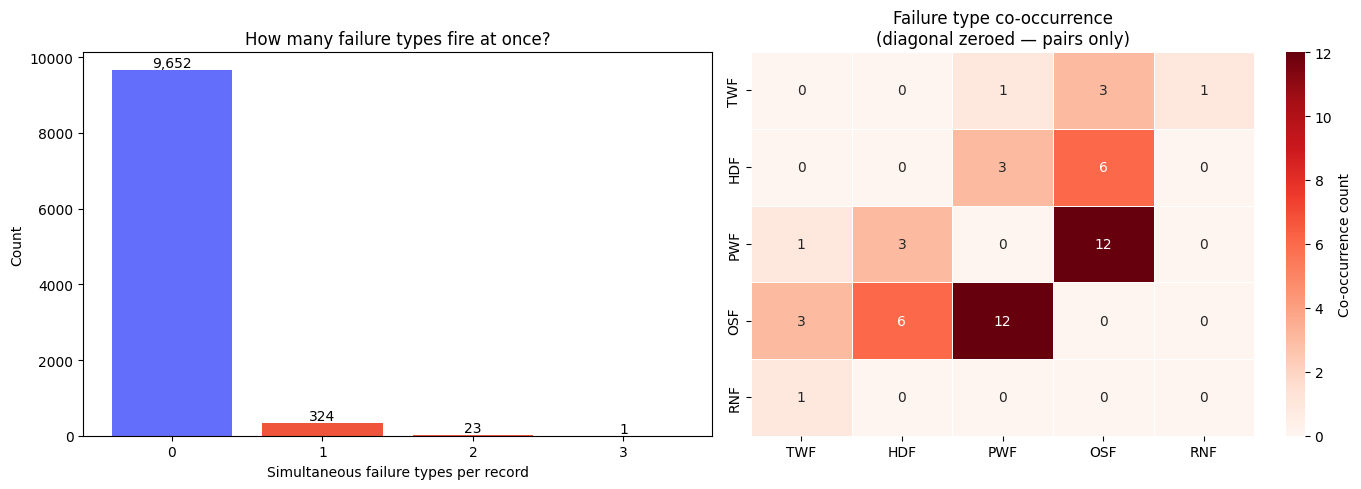

In [63]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df['failure_count'] = df[failure_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: how many failure types fire simultaneously per record
counts = df['failure_count'].value_counts().sort_index()
bar_colors = ['#636EFA' if i == 0 else '#EF553B' for i in counts.index]
axes[0].bar(counts.index.astype(str), counts.values, color=bar_colors)
axes[0].set_xlabel('Simultaneous failure types per record')
axes[0].set_ylabel('Count')
axes[0].set_title('How many failure types fire at once?')
for i, (x, v) in enumerate(zip(counts.index.astype(str), counts.values)):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontsize=10)

# Right: co-occurrence heatmap across failure records only
failures_only = df[df['Machine failure'] == 1]
cooccurrence = failures_only[failure_cols].T.dot(failures_only[failure_cols]).astype(int)
np.fill_diagonal(cooccurrence.values, 0)  # zero diagonal — pairs only, not self-counts
sns.heatmap(
    cooccurrence, annot=True, fmt='d', cmap='Reds', ax=axes[1],
    linewidths=0.5, cbar_kws={'label': 'Co-occurrence count'}
)
axes[1].set_title('Failure type co-occurrence\n(diagonal zeroed — pairs only)')

plt.tight_layout()
plt.show()

The dataset contains only 24 co-occurrence cases out of 10,000 records — insufficient for multilabel learning, so we treat failure prediction as binary and failure type identification as single-label multiclass.

The co-occurrence heatmap confirms that PWF+OSF is the dominant pairing (12 cases), followed by HDF+OSF (7 cases) and HDF+PWF (3 cases). All other combinations appear at most once. No combination is frequent enough for a model to learn a reliable pattern.